In [ ]:
import os
import pickle
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from torch.nn.functional import cosine_similarity

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
DATASET_PATH = "vox1_indian"

file_paths = []
labels = []
skipped_files = 0

for speaker_name in os.listdir(DATASET_PATH):
    speaker_folder = os.path.join(DATASET_PATH, speaker_name)
    if os.path.isdir(speaker_folder):
        for audio_file in os.listdir(speaker_folder):
            if audio_file.endswith(".wav"):
                full_path = os.path.join(speaker_folder, audio_file)
                if os.path.exists(full_path) and os.path.isfile(full_path):
                    try:
                        with open(full_path, 'rb') as f:
                            f.read(1)
                        file_paths.append(full_path)
                        labels.append(speaker_name)
                    except Exception as e:
                        skipped_files += 1
                        print(f"Skipping corrupted file: {full_path}")
                else:
                    skipped_files += 1
                    print(f"Skipping missing file: {full_path}")

print(f"Total audio files found: {len(file_paths)}")
print(f"Skipped files: {skipped_files}")
print(f"Speakers found: {set(labels)}")
print(f"Number of speakers: {len(set(labels))}")

Total audio files found: 2298
Skipped files: 0
Speakers found: {'Aamir_Khan', 'Pooja_Kumar', 'Vidya_Balan', 'Shraddha_Kapoor', 'John_Abraham', 'Mallika_Sherawat', 'Shahid_Kapoor', 'Amitabh_Bachchan', 'Suraj_Sharma', 'Ajay_Devgn', 'Freida_Pinto', 'Parineeti_Chopra', 'Sidharth_Malhotra', 'Tabu', 'Randeep_Hooda', 'Preity_Zinta', 'Kangana_Ranaut', 'Sonam_Kapoor', 'Ranbir_Kapoor', 'Irrfan_Khan', 'Om_Puri', 'Akshay_Kumar', 'Naseeruddin_Shah'}
Number of speakers: 23


In [5]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

NUM_CLASSES = len(label_encoder.classes_)
print(f"Speaker classes: {label_encoder.classes_}")
print(f"Encoded labels: {encoded_labels[:10]}")
print(f"Number of classes: {NUM_CLASSES}")

Speaker classes: ['Aamir_Khan' 'Ajay_Devgn' 'Akshay_Kumar' 'Amitabh_Bachchan'
 'Freida_Pinto' 'Irrfan_Khan' 'John_Abraham' 'Kangana_Ranaut'
 'Mallika_Sherawat' 'Naseeruddin_Shah' 'Om_Puri' 'Parineeti_Chopra'
 'Pooja_Kumar' 'Preity_Zinta' 'Ranbir_Kapoor' 'Randeep_Hooda'
 'Shahid_Kapoor' 'Shraddha_Kapoor' 'Sidharth_Malhotra' 'Sonam_Kapoor'
 'Suraj_Sharma' 'Tabu' 'Vidya_Balan']
Encoded labels: [0 0 0 0 0 0 0 0 0 0]
Number of classes: 23


In [6]:
train_files, test_files, train_labels, test_labels = train_test_split(
    file_paths,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)

print(f"Training files: {len(train_files)}")
print(f"Testing files:  {len(test_files)}")

Training files: 1838
Testing files:  460


In [7]:
def audio_to_melspectrogram(file_path, sample_rate=16000, n_mels=128, fixed_length=128):
    try:
        audio, sr = librosa.load(file_path, sr=sample_rate, mono=True)
        if len(audio) == 0:
            raise ValueError(f"Empty audio file: {file_path}")
        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=n_mels,
            n_fft=512,
            hop_length=256
        )
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        if log_mel_spec.shape[1] < fixed_length:
            pad_width = fixed_length - log_mel_spec.shape[1]
            log_mel_spec = np.pad(log_mel_spec, ((0, 0), (0, pad_width)), mode='constant')
        else:
            log_mel_spec = log_mel_spec[:, :fixed_length]
        return log_mel_spec.astype(np.float32)
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return np.zeros((n_mels, fixed_length), dtype=np.float32)

test_spec = audio_to_melspectrogram(file_paths[0])
print(f"Spectrogram shape: {test_spec.shape}")

c:\Users\ARYAN SINGH JADAUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Spectrogram shape: (128, 128)


In [8]:
def augment_spectrogram(spec):
    spec = spec.clone()
    num_time_masks = np.random.randint(0, 3)
    for _ in range(num_time_masks):
        time_mask_width = np.random.randint(5, 16)
        if spec.shape[2] > time_mask_width:
            time_start = np.random.randint(0, spec.shape[2] - time_mask_width)
            spec[:, :, time_start:time_start + time_mask_width] = -80
    num_freq_masks = np.random.randint(0, 3)
    for _ in range(num_freq_masks):
        freq_mask_width = np.random.randint(5, 16)
        if spec.shape[1] > freq_mask_width:
            freq_start = np.random.randint(0, spec.shape[1] - freq_mask_width)
            spec[:, freq_start:freq_start + freq_mask_width, :] = -80
    if np.random.rand() > 0.7:
        noise = torch.randn_like(spec) * 0.002
        spec = spec + noise
    return spec

class SpeakerDataset(Dataset):
    def __init__(self, file_paths, labels, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        file_path = self.file_paths[index]
        label = self.labels[index]
        try:
            spectrogram = audio_to_melspectrogram(file_path)
            spectrogram = torch.tensor(spectrogram).unsqueeze(0)
            if self.augment:
                spectrogram = augment_spectrogram(spectrogram)
            return spectrogram, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            print(f"Error loading {file_path}: {str(e)}")
            spectrogram = torch.zeros((1, 128, 128), dtype=torch.float32)
            return spectrogram, torch.tensor(label, dtype=torch.long)

train_dataset = SpeakerDataset(train_files, train_labels, augment=True)
test_dataset  = SpeakerDataset(test_files, test_labels, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")

Train batches: 115
Test batches:  29
Batch shape: torch.Size([16, 1, 128, 128])
Labels shape: torch.Size([16])


In [9]:
class SpeakerCNN(nn.Module):
    def __init__(self, num_classes, embedding_dim=512):
        super(SpeakerCNN, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.1)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.2)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.3)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.4)
        )
        
        self.conv_block5 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.5)
        )
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.embedding_layer = nn.Sequential(
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.conv_block5(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        embedding = self.embedding_layer(x)
        output = self.classifier(embedding)
        return output, embedding

model = SpeakerCNN(num_classes=NUM_CLASSES, embedding_dim=512).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SpeakerCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
optimizer = optim.AdamW(model.parameters(), lr=7e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=6,
    verbose=True,
    min_lr=1e-6
)

NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 20
MAX_GRAD_NORM = 3.0

print(f"Training config for {len(set(labels))} speakers")
print(f"Epochs: {NUM_EPOCHS} with early stopping (patience={EARLY_STOP_PATIENCE})")

Training config for 23 speakers
Epochs: 100 with early stopping (patience=20)


c:\Users\ARYAN SINGH JADAUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [11]:
train_acc_history = []
val_acc_history   = []
best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    correct_train = 0
    total_train   = 0
    running_loss  = 0.0
    
    for spectrograms, labels in train_loader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs, _ = model(spectrograms)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        running_loss += loss.item()
    
    train_accuracy = 100 * correct_train / total_train
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for spectrograms, labels in test_loader:
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)
            outputs, _ = model(spectrograms)
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
    
    val_accuracy = 100 * correct_val / total_val
    scheduler.step(val_accuracy)
    current_lr = optimizer.param_groups[0]['lr']
    train_acc_history.append(train_accuracy)
    val_acc_history.append(val_accuracy)
    
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "model_best.pth")
    else:
        epochs_without_improvement += 1
    
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}% | Loss: {avg_train_loss:.4f} | LR: {current_lr:.6f}")
    
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("\nTraining Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Epoch [ 1/100] | Train Acc: 5.28% | Val Acc: 8.70% | Loss: 3.2395 | LR: 0.000700
Epoch [ 2/100] | Train Acc: 8.00% | Val Acc: 12.17% | Loss: 2.9727 | LR: 0.000700
Epoch [ 3/100] | Train Acc: 11.97% | Val Acc: 16.52% | Loss: 2.8061 | LR: 0.000700
Epoch [ 4/100] | Train Acc: 11.86% | Val Acc: 9.78% | Loss: 2.7610 | LR: 0.000700
Epoch [ 5/100] | Train Acc: 12.13% | Val Acc: 16.52% | Loss: 2.7232 | LR: 0.000700
Epoch [ 6/100] | Train Acc: 16.05% | Val Acc: 14.35% | Loss: 2.6391 | LR: 0.000700
Epoch [ 7/100] | Train Acc: 15.89% | Val Acc: 24.35% | Loss: 2.6233 | LR: 0.000700
Epoch [ 8/100] | Train Acc: 16.76% | Val Acc: 25.65% | Loss: 2.5853 | LR: 0.000700
Epoch [ 9/100] | Train Acc: 18.66% | Val Acc: 20.43% | Loss: 2.5010 | LR: 0.000700
Epoch [10/100] | Train Acc: 18.50% | Val Acc: 25.00% | Loss: 2.5061 | LR: 0.000700
Epoch [11/100] | Train Acc: 20.89% | Val Acc: 27.83% | Loss: 2.4501 | LR: 0.000700
Epoch [12/100] | Train Acc: 21.87% | Val Acc: 31.96% | Loss: 2.3917 | LR: 0.000700
Epoch [1

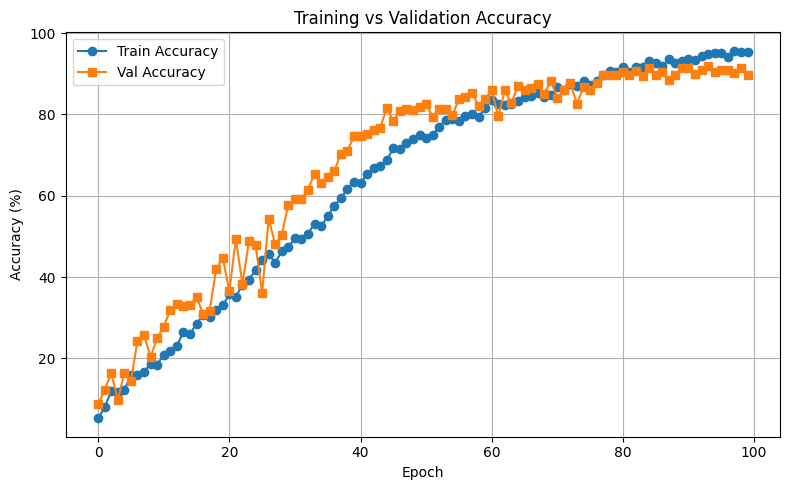

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label="Train Accuracy", marker='o')
plt.plot(val_acc_history,   label="Val Accuracy",   marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
torch.save(model.state_dict(), "model.pth")
print("Final model saved as model.pth")
print(f"Best model saved as model_best.pth (Val Acc: {best_val_acc:.2f}%)")

Final model saved as model.pth
Best model saved as model_best.pth (Val Acc: 91.96%)


In [14]:
def get_embedding(file_path, model, device):
    spec = audio_to_melspectrogram(file_path)
    spec_tensor = torch.tensor(spec).unsqueeze(0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        _, embedding = model(spec_tensor)
    return embedding.squeeze(0).cpu().numpy()

speaker_embeddings = {}

print("Building speaker embedding database...")

for file_path, label_idx in zip(file_paths, encoded_labels):
    speaker_name = label_encoder.classes_[label_idx]
    embedding = get_embedding(file_path, model, device)
    if speaker_name not in speaker_embeddings:
        speaker_embeddings[speaker_name] = []
    speaker_embeddings[speaker_name].append(embedding)

voice_db = {}
for speaker_name, emb_list in speaker_embeddings.items():
    voice_db[speaker_name] = np.mean(np.stack(emb_list), axis=0)
    print(f"  {speaker_name}: averaged {len(emb_list)} embeddings")

with open("voice_db.pkl", "wb") as f:
    pickle.dump(voice_db, f)

print("\nVoice database saved as voice_db.pkl")
print(f"Database keys: {list(voice_db.keys())}")
print(f"Embedding dimension: {voice_db[list(voice_db.keys())[0]].shape[0]}")

Building speaker embedding database...
  Aamir_Khan: averaged 106 embeddings
  Ajay_Devgn: averaged 76 embeddings
  Akshay_Kumar: averaged 92 embeddings
  Amitabh_Bachchan: averaged 141 embeddings
  Freida_Pinto: averaged 72 embeddings
  Irrfan_Khan: averaged 133 embeddings
  John_Abraham: averaged 70 embeddings
  Kangana_Ranaut: averaged 123 embeddings
  Mallika_Sherawat: averaged 94 embeddings
  Naseeruddin_Shah: averaged 108 embeddings
  Om_Puri: averaged 99 embeddings
  Parineeti_Chopra: averaged 100 embeddings
  Pooja_Kumar: averaged 102 embeddings
  Preity_Zinta: averaged 114 embeddings
  Ranbir_Kapoor: averaged 101 embeddings
  Randeep_Hooda: averaged 105 embeddings
  Shahid_Kapoor: averaged 102 embeddings
  Shraddha_Kapoor: averaged 102 embeddings
  Sidharth_Malhotra: averaged 87 embeddings
  Sonam_Kapoor: averaged 100 embeddings
  Suraj_Sharma: averaged 111 embeddings
  Tabu: averaged 55 embeddings
  Vidya_Balan: averaged 105 embeddings

Voice database saved as voice_db.pkl
Da

In [15]:
def identify_speaker(audio_path, model, voice_db, device, threshold=0.75):
    input_embedding = get_embedding(audio_path, model, device)
    input_tensor    = torch.tensor(input_embedding).unsqueeze(0)
    best_speaker    = None
    best_similarity = -1
    
    for speaker_name, db_embedding in voice_db.items():
        db_tensor = torch.tensor(db_embedding).unsqueeze(0)
        similarity = cosine_similarity(input_tensor, db_tensor).item()
        if similarity > best_similarity:
            best_similarity = similarity
            best_speaker    = speaker_name
    
    if best_similarity >= threshold:
        status = "Authenticated"
    else:
        status = "Voice Not Found"
        best_speaker = "Unknown"
    
    return {
        "predicted_name"  : best_speaker,
        "similarity_score": round(float(best_similarity), 4),
        "status"          : status
    }

print("identify_speaker() function ready")

identify_speaker() function ready


In [16]:
loaded_model = SpeakerCNN(num_classes=NUM_CLASSES, embedding_dim=512).to(device)
loaded_model.load_state_dict(torch.load("model_best.pth", map_location=device))
loaded_model.eval()

with open("voice_db.pkl", "rb") as f:
    loaded_voice_db = pickle.load(f)

print("✓ Model and voice_db loaded successfully")
print(f"✓ Parameters: {sum(p.numel() for p in loaded_model.parameters()):,}")
print(f"✓ Speakers: {list(loaded_voice_db.keys())}")

✓ Model and voice_db loaded successfully
✓ Parameters: 9,685,207
✓ Speakers: [np.str_('Aamir_Khan'), np.str_('Ajay_Devgn'), np.str_('Akshay_Kumar'), np.str_('Amitabh_Bachchan'), np.str_('Freida_Pinto'), np.str_('Irrfan_Khan'), np.str_('John_Abraham'), np.str_('Kangana_Ranaut'), np.str_('Mallika_Sherawat'), np.str_('Naseeruddin_Shah'), np.str_('Om_Puri'), np.str_('Parineeti_Chopra'), np.str_('Pooja_Kumar'), np.str_('Preity_Zinta'), np.str_('Ranbir_Kapoor'), np.str_('Randeep_Hooda'), np.str_('Shahid_Kapoor'), np.str_('Shraddha_Kapoor'), np.str_('Sidharth_Malhotra'), np.str_('Sonam_Kapoor'), np.str_('Suraj_Sharma'), np.str_('Tabu'), np.str_('Vidya_Balan')]


C:\Users\ARYAN SINGH JADAUN\AppData\Local\Temp\ipykernel_21356\2438371402.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("model_

In [17]:
test_audio_path = test_files[7]
actual_label    = label_encoder.classes_[test_labels[7]]

print(f"Testing on : {test_audio_path}")
print(f"Actual speaker: {actual_label}")
print("-" * 40)

result = identify_speaker(
    audio_path = test_audio_path,
    model      = loaded_model,
    voice_db   = loaded_voice_db,
    device     = device,
    threshold  = 0.75
)

print(f"Predicted Name   : {result['predicted_name']}")
print(f"Similarity Score : {result['similarity_score']}")
print(f"Status           : {result['status']}")
print("-" * 40)
print("Correct!" if result['predicted_name'] == actual_label else "Incorrect prediction")

Testing on : vox1_indian\Suraj_Sharma\1 (64).wav
Actual speaker: Suraj_Sharma
----------------------------------------
Predicted Name   : Suraj_Sharma
Similarity Score : 0.889
Status           : Authenticated
----------------------------------------
Correct!
